1)	Impor Library & Set Seed

In [1]:
import torch
import  numpy as np
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedKFold



2)	Impor & Cek Dataset

In [2]:
data_dir = r"D:/COOLYEAH/SEMESTER 6/DEEP LEARNING CITRA MEDIS/DATA"

In [3]:
import os

print(os.listdir( r"D:/COOLYEAH/SEMESTER 6/DEEP LEARNING CITRA MEDIS/DATA"))

['glioma', 'meningioma', 'notumor', 'pituitary']


3)	Exploratory Data Analysis (EDA)

In [4]:
dataset_eda = datasets.ImageFolder(
    root=data_dir,
    transform=None
)

In [5]:
targets_eda = dataset_eda.targets

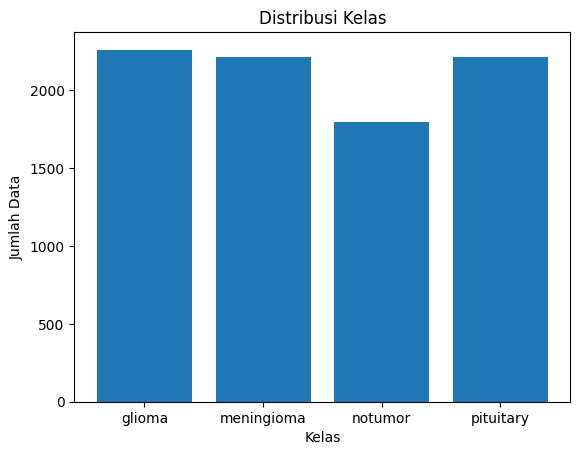

In [6]:
class_counts = np.bincount(targets_eda)
class_names = dataset_eda.classes

plt.bar(class_names, class_counts)
plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.show()

C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


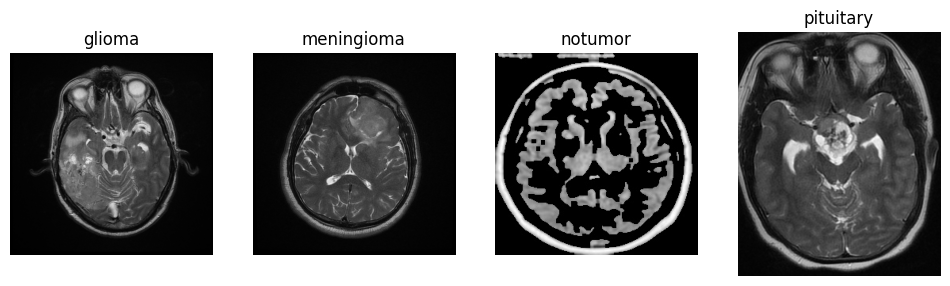

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

shown = set()
i = 0

for idx in range(len(dataset_eda)):
    img, label = dataset_eda[idx]

    if label not in shown:
        axes[i].imshow(img)  
        axes[i].set_title(class_names[label])
        axes[i].axis('off')

        shown.add(label)
        i += 1

    if i == 4:
        break

plt.show()

4)	Preprocessing & Augmentasi

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

5)	Splitting Data

In [21]:
base_dataset = datasets.ImageFolder(root=data_dir, transform=None)
targets = base_dataset.targets

all_indices = list(range(len(targets)))

trainval_idx, test_idx = train_test_split(
    all_indices, test_size=0.10,
    stratify=targets, random_state=42
)

print(f'Train+Val (K-Fold) : {len(trainval_idx)} gambar')
print(f'Test set           : {len(test_idx)} gambar')
print(f'Total              : {len(trainval_idx)+len(test_idx)} gambar')

Train+Val (K-Fold) : 7634 gambar
Test set           : 849 gambar
Total              : 8483 gambar


Tambah K-Fold


In [22]:
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_skf  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies = []
trainval_targets_arr = [targets[i] for i in trainval_idx]

7)	Inisialisasi Model

In [23]:
model = models.resnet18(pretrained=True)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8)	Set Loss, Optimizer, dan Scheduler

In [24]:
class_counts = np.array([2259, 2214, 1796, 2214])

class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()

class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [26]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

9)	Training dan Validation

In [39]:
# ===== TRAINING K-FOLD (hanya dari trainval_idx) =====
best_overall_acc = 0  # tracker model terbaik across semua fold

for fold, (train_idx, val_idx) in enumerate(outer_skf.split(np.zeros(len(trainval_idx)), trainval_targets_arr)):

    print(f'\n===== FOLD {fold+1} =====')

    train_global = [trainval_idx[i] for i in train_idx]
    val_global   = [trainval_idx[i] for i in val_idx]
    train_targets_inner = [targets[i] for i in train_global]

    # ===== INNER OPTUNA =====
    def objective(trial):
        lr             = trial.suggest_categorical('lr', [1e-5, 1e-4, 1e-3])
        batch_size     = trial.suggest_categorical('batch_size', [8, 16, 32])
        optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

        t_idx, v_idx = next(inner_skf.split(
            np.zeros(len(train_global)), train_targets_inner))
        t_sub = [train_global[i] for i in t_idx]
        v_sub = [train_global[i] for i in v_idx]

        m = models.resnet18(pretrained=True)
        m.fc = nn.Linear(m.fc.in_features, 4)
        m = m.to(device)

        cw = 1. / torch.tensor([2259,2214,1796,2214], dtype=torch.float)
        cw = (cw / cw.sum()).to(device)
        crit = nn.CrossEntropyLoss(weight=cw)

        if optimizer_name == 'Adam':
            opt = optim.Adam(m.parameters(), lr=lr)
        else:
            opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)

        t_loader = DataLoader(
            Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), t_sub),
            batch_size=batch_size, shuffle=True)
        v_loader = DataLoader(
            Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), v_sub),
            batch_size=batch_size, shuffle=False)

        for _ in range(3):
            m.train()
            for imgs, lbls in t_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                opt.zero_grad()
                crit(m(imgs), lbls).backward()
                opt.step()

        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in v_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                _, pred = torch.max(m(imgs), 1)
                total += lbls.size(0)
                correct += (pred == lbls).sum().item()
        return correct / total

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=6, show_progress_bar=False)
    best = study.best_params
    print(f'  Best params fold {fold+1}: {best}')

    # ===== OUTER TRAINING pakai best params =====
    train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_global)
    val_dataset   = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform),   val_global)

    train_loader = DataLoader(train_dataset, batch_size=best['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=best['batch_size'], shuffle=False)

    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    if best['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=best['lr'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=best['lr'], momentum=0.9)

    epochs = 5
    best_fold_acc = 0        # tracker epoch terbaik dalam fold ini
    best_model_state = None  # simpan state terbaik di memori

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                _, predicted = torch.max(model(images), 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f'Fold {fold+1} | Epoch {epoch+1} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%')

        # ===== SIMPAN EPOCH TERBAIK DALAM FOLD INI =====
        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f'  -> Best epoch fold {fold+1}: {val_acc:.2f}%')

    # Load balik state terbaik fold ini sebelum evaluasi
    model.load_state_dict(best_model_state)
    fold_accuracies.append(best_fold_acc)  # catat best epoch, bukan epoch terakhir

    # ===== SIMPAN MODEL TERBAIK ACROSS SEMUA FOLD =====
    if best_fold_acc > best_overall_acc:
        best_overall_acc = best_fold_acc
        torch.save(model.state_dict(), 'brain_tumor_resnet_best.pth')
        print(f'  -> Best overall model disimpan! Acc: {best_overall_acc:.2f}%')


===== FOLD 1 =====


C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained'

  Best params fold 1: {'lr': 0.001, 'batch_size': 16, 'optimizer': 'SGD'}
Fold 1 | Epoch 1 | Loss: 0.5519 | Val Acc: 86.12%
  -> Best epoch fold 1: 86.12%
Fold 1 | Epoch 2 | Loss: 0.2314 | Val Acc: 89.91%
  -> Best epoch fold 1: 89.91%
Fold 1 | Epoch 3 | Loss: 0.1014 | Val Acc: 92.21%
  -> Best epoch fold 1: 92.21%
Fold 1 | Epoch 4 | Loss: 0.0608 | Val Acc: 92.27%
  -> Best epoch fold 1: 92.27%
Fold 1 | Epoch 5 | Loss: 0.0525 | Val Acc: 93.45%
  -> Best epoch fold 1: 93.45%
  -> Best overall model disimpan! Acc: 93.45%

===== FOLD 2 =====


C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained'

  Best params fold 2: {'lr': 0.0001, 'batch_size': 16, 'optimizer': 'Adam'}
Fold 2 | Epoch 1 | Loss: 0.4435 | Val Acc: 90.31%
  -> Best epoch fold 2: 90.31%
Fold 2 | Epoch 2 | Loss: 0.1706 | Val Acc: 93.98%
  -> Best epoch fold 2: 93.98%
Fold 2 | Epoch 3 | Loss: 0.0798 | Val Acc: 93.25%
Fold 2 | Epoch 4 | Loss: 0.0721 | Val Acc: 93.78%
Fold 2 | Epoch 5 | Loss: 0.0530 | Val Acc: 93.84%
  -> Best overall model disimpan! Acc: 93.98%

===== FOLD 3 =====


...

  Best params fold 3: {'lr': 0.001, 'batch_size': 16, 'optimizer': 'SGD'}
Fold 3 | Epoch 1 | Loss: 0.5646 | Val Acc: 88.87%
  -> Best epoch fold 3: 88.87%
Fold 3 | Epoch 2 | Loss: 0.2413 | Val Acc: 91.88%
  -> Best epoch fold 3: 91.88%
Fold 3 | Epoch 3 | Loss: 0.1204 | Val Acc: 90.05%
Fold 3 | Epoch 4 | Loss: 0.0673 | Val Acc: 93.65%
  -> Best epoch fold 3: 93.65%
Fold 3 | Epoch 5 | Loss: 0.0344 | Val Acc: 93.52%

===== FOLD 4 =====


C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained'

  Best params fold 4: {'lr': 0.001, 'batch_size': 8, 'optimizer': 'Adam'}
Fold 4 | Epoch 1 | Loss: 0.7506 | Val Acc: 78.98%
  -> Best epoch fold 4: 78.98%
Fold 4 | Epoch 2 | Loss: 0.5120 | Val Acc: 80.94%
  -> Best epoch fold 4: 80.94%
Fold 4 | Epoch 3 | Loss: 0.4206 | Val Acc: 82.71%
  -> Best epoch fold 4: 82.71%
Fold 4 | Epoch 4 | Loss: 0.3279 | Val Acc: 83.43%
  -> Best epoch fold 4: 83.43%
Fold 4 | Epoch 5 | Loss: 0.2421 | Val Acc: 87.95%
  -> Best epoch fold 4: 87.95%

===== FOLD 5 =====


C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained'

  Best params fold 5: {'lr': 0.001, 'batch_size': 8, 'optimizer': 'SGD'}
Fold 5 | Epoch 1 | Loss: 0.5816 | Val Acc: 87.48%
  -> Best epoch fold 5: 87.48%
Fold 5 | Epoch 2 | Loss: 0.2867 | Val Acc: 87.42%
Fold 5 | Epoch 3 | Loss: 0.1851 | Val Acc: 91.68%
  -> Best epoch fold 5: 91.68%
Fold 5 | Epoch 4 | Loss: 0.1200 | Val Acc: 93.25%
  -> Best epoch fold 5: 93.25%
Fold 5 | Epoch 5 | Loss: 0.0913 | Val Acc: 94.50%
  -> Best epoch fold 5: 94.50%
  -> Best overall model disimpan! Acc: 94.50%


In [41]:
test_dataset = Subset(
    datasets.ImageFolder(root=data_dir, transform=val_transform),
    test_idx
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
print(f'Jumlah data test: {len(test_dataset)} gambar')

Jumlah data test: 849 gambar


10)	Testing dan Model

In [42]:
model.eval()

correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total

print("Accuracy:", accuracy)

# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

# ==========================
# Precision Recall F1-score
# ==========================

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# ==========================
# MSE dan RMSE (opsional)
# ==========================

mse = np.mean((np.array(all_labels) - np.array(all_preds))**2)
rmse = np.sqrt(mse)

print("\nMSE:", mse)
print("RMSE:", rmse)

Accuracy: 94.11071849234393

Confusion Matrix:
[[207  13   2   4]
 [ 13 200   4   5]
 [  1   0 179   0]
 [  4   4   0 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       226
           1       0.92      0.90      0.91       222
           2       0.97      0.99      0.98       180
           3       0.96      0.96      0.96       221

    accuracy                           0.94       849
   macro avg       0.94      0.94      0.94       849
weighted avg       0.94      0.94      0.94       849


MSE: 0.17667844522968199
RMSE: 0.42033135170919855


11) Menyimpan Model

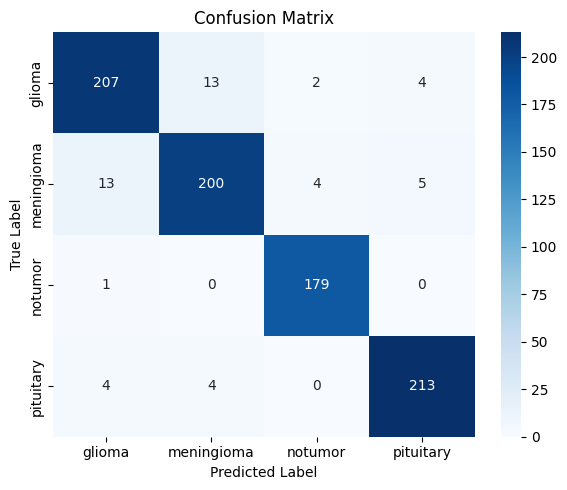

In [43]:
import seaborn as sns

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(),"brain_tumor_resnet fikss.pth")

print("Model saved!")

Model saved!


12) Visualisasi Confusion Matrix